# Diagnosing & Predicting Viewer Drop-Off in OTT Platforms
### A Data Science + Product Analytics Project

**Business problem:** OTT platforms often achieve strong launch viewership, but a significant proportion of viewers disengage during Season 1, impacting user lifetime value and complicating content renewal decisions. This project uses episode-level content-design and viewer-behavior data to:

1. Diagnose *why* and *where* viewer drop-off happens during a season.
2. Build machine learning models to predict per-episode drop-off risk using content-design and engagement features.
3. Identify the key drivers of viewer drop-off using model explainability techniques (SHAP).
4. Turn the findings into prioritized, risk-aware product recommendations.

**Target Definition & Leakage Handling:** Before building predictive models, I analyzed the target variables and identified potential leakage risks. The dataset contains drop_off, drop_off_probability, and retention_risk, which are derived from the same underlying score. These variables were carefully separated from the modeling features to ensure the model learns meaningful patterns from available features instead of relying on information that would not be available during prediction.


## 1. Data Loading & Understanding

In [1]:
import pandas as pd
import numpy as np

pd.set_option("display.max_columns", 30)
pd.set_option("display.width", 160)

df = pd.read_csv("ott_viewer_dropoff_retention_us_v1.0.csv")

print(df.shape)
df.head()


(33171, 23)


,show_id,title,platform,genre,release_year,season_number,episode_number,episode_duration_min,pacing_score,hook_strength,dialogue_density,visual_intensity,avg_watch_percentage,pause_count,rewind_count,skip_intro,cognitive_load,attention_required,night_watch_safe,drop_off,drop_off_probability,retention_risk,dataset_version
0,66732,Stranger Things,Netflix,Sci-Fi & Fantasy,2016.0,1,1,48,4,5,high,5,39,3,0,0,9,high,0,1,0.649,high,v1.0
1,66732,Stranger Things,Netflix,Sci-Fi & Fantasy,2016.0,1,2,55,5,4,low,8,55,3,3,1,5,medium,0,0,0.473,medium,v1.0
2,66732,Stranger Things,Netflix,Sci-Fi & Fantasy,2016.0,1,3,51,4,8,high,7,46,4,2,0,9,high,0,0,0.583,medium,v1.0
3,66732,Stranger Things,Netflix,Sci-Fi & Fantasy,2016.0,1,4,50,4,7,medium,3,50,4,1,0,7,high,0,0,0.520,medium,v1.0
4,66732,Stranger Things,Netflix,Sci-Fi & Fantasy,2016.0,1,5,52,4,3,low,4,35,3,0,1,7,high,0,1,0.638,high,v1.0


In [2]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 33171 entries, 0 to 33170
Data columns (total 23 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   show_id               33171 non-null  int64  
 1   title                 33171 non-null  str    
 2   platform              33171 non-null  str    
 3   genre                 33171 non-null  str    
 4   release_year          33171 non-null  float64
 5   season_number         33171 non-null  int64  
 6   episode_number        33171 non-null  int64  
 7   episode_duration_min  33171 non-null  int64  
 8   pacing_score          33171 non-null  int64  
 9   hook_strength         33171 non-null  int64  
 10  dialogue_density      33171 non-null  str    
 11  visual_intensity      33171 non-null  int64  
 12  avg_watch_percentage  33171 non-null  int64  
 13  pause_count           33171 non-null  int64  
 14  rewind_count          33171 non-null  int64  
 15  skip_intro            33171 no

In [3]:
# Basic sanity checks
print("Missing values:\n", df.isnull().sum().sum(), "total")
print("\nUnique shows:", df['show_id'].nunique(), "| Unique episodes:", len(df))
print("season_number unique values:", df['season_number'].unique(), "-> dataset is Season 1 only, matches business problem")
print("\ndrop_off rate:", df['drop_off'].mean().round(4))

# Duplicate check (explicitly required by the case-study validation checklist,
# and easy to miss since there are no exact full-row duplicates).
print("\nExact duplicate rows:", df.duplicated().sum())
dup_mask = df.duplicated(subset=["show_id", "episode_number"], keep=False)
dup_groups = df[dup_mask].groupby(["show_id", "episode_number"])["platform"].nunique()
multi_platform = (dup_groups > 1).sum()   # same show+episode, different platform -> real, separate rows
true_conflict = (dup_groups == 1).sum()   # same show+episode+platform, contradictory values -> data-quality issue
print(f"(show_id, episode_number) collisions: {len(dup_groups)} groups")
print(f"  -> {multi_platform} are the same show legitimately airing on >1 platform "
      f"(distinct on (show_id, episode_number, platform)) - keep both rows")
print(f"  -> {true_conflict} are true duplicate-key conflicts (same show+episode+platform, "
      f"contradictory values) -> handled in Section 2")

# Outlier check on numeric columns (also explicitly required by the checklist).
# Bounded/scored columns (pacing_score, hook_strength, cognitive_load, etc.) are all
# within tight, plausible ranges - the one column worth a close look is duration.
print("\nepisode_duration_min percentiles:")
print(df["episode_duration_min"].describe(percentiles=[.01, .25, .5, .75, .99, .999]).round(1))
print("Rows with duration > 200 min:", (df["episode_duration_min"] > 200).sum(),
      "-> handled in Section 2")

# Show-size concentration check: how evenly are episodes spread across the 489 shows?
ep_per_show = df.groupby("show_id")["episode_number"].nunique().sort_values(ascending=False)
print(f"\nEpisodes-per-show (unique episode numbers): median={ep_per_show.median():.0f}, max={ep_per_show.max()}")
print(f"Top 10 shows ({10/df['show_id'].nunique():.1%} of shows) account for "
      f"{ep_per_show.head(10).sum()/df['episode_number'].count():.1%} of all episodes")


Missing values:
 0 total

Unique shows: 489 | Unique episodes: 33171
season_number unique values: [1] -> dataset is Season 1 only, matches business problem

drop_off rate: 0.1448

Exact duplicate rows: 0
(show_id, episode_number) collisions: 1284 groups
  -> 260 are the same show legitimately airing on >1 platform (distinct on (show_id, episode_number, platform)) - keep both rows
  -> 1024 are true duplicate-key conflicts (same show+episode+platform, contradictory values) -> handled in Section 2

episode_duration_min percentiles:
count    33171.0
mean        37.7
std         22.9
min          1.0
1%           6.0
25%         24.0
50%         33.0
75%         49.0
99%         95.0
99.9%      147.0
max       1225.0
Name: episode_duration_min, dtype: float64
Rows with duration > 200 min: 1 -> handled in Section 2

Episodes-per-show (unique episode numbers): median=16, max=2650
Top 10 shows (2.0% of shows) account for 42.1% of all episodes


**Takeaway:** The dataset contains 33,171 episode-level records across 489 shows with no missing values and no exact duplicate rows. Since all records belong to Season 1, the dataset aligns with the business objective of understanding early-season viewer drop-off. The overall drop-off rate is approximately 14.5%, indicating that this is an imbalanced classification problem.

**Three data-quality points to handle before analysis (all addressed in Section 2):**

1. **Duplicate keys — but not all of them are actually duplicates.** 1,284 `(show_id, episode_number)` pairs collide. Splitting these apart by platform is important:
   - **260 collisions are legitimate, not a bug:** they all belong to a single show, *Plus belle la vie*, which airs on both Hulu and Prime Video. Once `platform` is added to the key, all 520 of its rows (260 episodes × 2 platforms) are unique — each is a real, separate engagement record and must be kept.
   - **1,024 collisions are genuine duplicate-key conflicts** — same show, same episode, *same platform* — across the other 10 shows, with contradictory values on nearly every column (`drop_off_probability` differs in 99.8% of these pairs, `drop_off` itself in 25.5%). And for every one of these 10 shows, literally every episode is duplicated exactly once (e.g. show 35024 has 1,792 rows across only 896 unique episode numbers) — that "whole show doubled" pattern points to an ingestion artifact, not real signal.
   - The correct de-duplication key is therefore **`(show_id, episode_number, platform)`**, not `(show_id, episode_number)` — deduping on the latter would have silently discarded half of *Plus belle la vie*'s legitimate multi-platform data.
2. **An implausible outlier:** one episode (`Doraemon`, episode 238) is logged at **1,225 minutes** (~20 hours), vs. that same show's other 1,444 episodes running 8–39 minutes. Clearly a data-entry error, not a real episode length.
3. **Heavy show-size skew:** episode count per show ranges from 1 to 2,650, with a median of only 16. The **top 10 shows (2% of shows) account for a large share of all episodes.** This doesn't bias the category-bucketing logic (already computed per-show, not per-row), but it matters for how the train/test split is evaluated — addressed with a robustness check in Section 6.


## 2. Data Cleaning & Preprocessing

Decisions made here (and why):
- Drop `title`, `dataset_version`, `season_number` — identifiers or constant columns that do not provide predictive value.
- **De-duplicate on `(show_id, episode_number, platform)`, keeping the first occurrence.** As established in Section 1, `(show_id, episode_number)` alone is *not* a safe key — one show is legitimately multi-platform, so naively deduping on the 2-column key would delete real data. Adding `platform` to the key resolves this exactly: it keeps both of *Plus belle la vie*'s platform rows intact, while still catching and removing the 1,024 true duplicate-key conflicts (same show+episode+platform, contradictory values) from the other 10 affected shows.
- **Drop the single episode with `episode_duration_min` > 200** (1,225 minutes for one `Doraemon` episode, ~50x that show's own typical length) — an isolated data-entry error, not a real outlier worth modeling around.
- Encode `dialogue_density` (low/medium/high) and `attention_required` (medium/high) as ordinal features because these categories have a natural ranking. One-hot encoding would remove this ordering information.
- **Split by `show_id`, not by individual row**, before any further analysis — episodes from the same show share content characteristics such as genre and platform. A random row split could leak information from the same show into both training and testing sets.
- Bucket rare `platform`/`genre` values (fewer than 5 shows) into `"Other"` before one-hot encoding, to avoid creating sparse dummy variables with very few examples. **This is fit on the training shows only, after the split** (not on the full dataset) — otherwise the "which categories are rare" decision would be informed by the test set's distribution, which is a subtle leak even though it doesn't touch the target.


In [4]:
df_clean = df.drop(columns=["title", "dataset_version", "season_number"]).copy()

# De-duplicate on (show_id, episode_number, platform) - NOT just (show_id, episode_number).
# The 2-column key is unsafe: one show (Plus belle la vie) legitimately airs on two
# platforms, so every one of its episodes has two genuine rows. Adding platform to the
# key keeps those intact while still removing the true duplicate-key conflicts elsewhere.
before = len(df_clean)
df_clean = df_clean.drop_duplicates(subset=["show_id", "episode_number", "platform"], keep="first").reset_index(drop=True)
print(f"Removed {before - len(df_clean)} duplicate (show_id, episode_number, platform) rows -> {len(df_clean)} rows remain")

# Drop the single implausible duration outlier (see Section 1).
before = len(df_clean)
df_clean = df_clean[df_clean["episode_duration_min"] <= 200].reset_index(drop=True)
print(f"Removed {before - len(df_clean)} row(s) with episode_duration_min > 200 -> {len(df_clean)} rows remain")

df_clean["dialogue_density"] = df_clean["dialogue_density"].map({"low": 0, "medium": 1, "high": 2})
df_clean["attention_required"] = df_clean["attention_required"].map({"medium": 0, "high": 1})


Removed 1024 duplicate (show_id, episode_number, platform) rows -> 32147 rows remain
Removed 1 row(s) with episode_duration_min > 200 -> 32146 rows remain


In [5]:
from sklearn.model_selection import GroupShuffleSplit

TEST_SIZE = 0.2
RANDOM_STATE = 42

gss = GroupShuffleSplit(n_splits=1, test_size=TEST_SIZE, random_state=RANDOM_STATE)
train_idx, test_idx = next(gss.split(df_clean, groups=df_clean["show_id"]))
train_df, test_df = df_clean.iloc[train_idx].copy(), df_clean.iloc[test_idx].copy()

print(f"Train: {len(train_df)} rows, {train_df['show_id'].nunique()} shows, drop_off rate {train_df['drop_off'].mean():.3f}")
print(f"Test:  {len(test_df)} rows, {test_df['show_id'].nunique()} shows, drop_off rate {test_df['drop_off'].mean():.3f}")
assert set(train_df['show_id']).isdisjoint(set(test_df['show_id'])), "Show leakage between train/test!"
print("No show_id overlap between train and test - confirmed.")

# Given the show-size skew flagged in Section 1, check how concentrated this particular
# test split is - i.e. are the reported metrics really an average over many held-out
# shows, or dominated by one or two mega-shows that happened to land in test?
test_by_show = test_df.groupby("show_id").size().sort_values(ascending=False)
print(f"\nLargest show in this test split: {test_by_show.iloc[0]} rows "
      f"({test_by_show.iloc[0]/len(test_df):.1%} of test)")
print(f"Top 3 shows in this test split account for "
      f"{test_by_show.head(3).sum()/len(test_df):.1%} of test rows")
print("This concentration is a structural property of the data (see Section 1), not a bad "
      "random draw - Section 6 checks it doesn't make the headline metric a fluke.")

# --- Rare-category bucketing: fit on TRAIN shows only, then apply everywhere ---
RARE_THRESHOLD = 5  # shows; platforms/genres with fewer shows than this (in TRAIN) get bucketed to "Other"

def get_rare_categories(data, col, threshold=RARE_THRESHOLD):
    show_counts = data.drop_duplicates("show_id")[col].value_counts()
    return show_counts[show_counts < threshold].index

def apply_rare_bucket(data, col, rare_categories):
    data = data.copy()
    data[col] = data[col].where(~data[col].isin(rare_categories), other="Other")
    return data

rare_platforms = get_rare_categories(train_df, "platform")
rare_genres = get_rare_categories(train_df, "genre")

train_df = apply_rare_bucket(train_df, "platform", rare_platforms)
train_df = apply_rare_bucket(train_df, "genre", rare_genres)
test_df = apply_rare_bucket(test_df, "platform", rare_platforms)
test_df = apply_rare_bucket(test_df, "genre", rare_genres)

# Any platform/genre value that never appears in train at all also becomes "Other" in test,
# since the model has no way to have learned anything about it.
for col in ["platform", "genre"]:
    unseen = set(test_df[col].unique()) - set(train_df[col].unique())
    if unseen:
        test_df[col] = test_df[col].where(~test_df[col].isin(unseen), other="Other")

# Keep df_clean consistent with the train-fit bucketing, since Section 5 re-derives
# train/test from df_clean using this same show_id split.
df_clean = pd.concat([train_df, test_df]).sort_index()

print(train_df["platform"].value_counts())
print()
print(train_df["genre"].value_counts())


Train: 24417 rows, 391 shows, drop_off rate 0.147
Test:  7729 rows, 98 shows, drop_off rate 0.138
No show_id overlap between train and test - confirmed.

Largest show in this test split: 2650 rows (34.3% of test)
Top 3 shows in this test split account for 59.0% of test rows
This concentration is a structural property of the data (see Section 1), not a bad random draw - Section 6 checks it doesn't make the headline metric a fluke.
platform
Netflix                             9154
Hulu                                5798
Other                               3348
Disney+                             2021
Prime Video                         1853
Peacock Premium                      656
fuboTV                               522
Crunchyroll                          382
Paramount Plus Apple TV Channel      236
HBO Max                              229
Britbox Apple TV Channel             167
Apple TV                              51
Name: count, dtype: int64

genre
Animation             7045
Actio

## 3. Leakage Analysis & Feature Decisions

The dataset includes three outcome-adjacent columns: `drop_off`, `drop_off_probability`, `retention_risk`. before using any of these variables as model input, it's worth checking how they actually relate — because if they're not independent signals, using more than one as a feature is just leaking the label into the inputs.

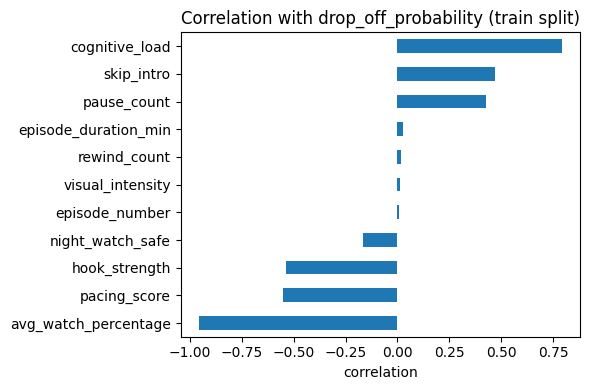

cognitive_load          0.792433
skip_intro              0.471304
pause_count             0.426889
episode_duration_min    0.027529
rewind_count            0.016255
visual_intensity        0.012938
episode_number          0.009593
night_watch_safe       -0.163879
hook_strength          -0.538938
pacing_score           -0.553142
avg_watch_percentage   -0.957163
Name: drop_off_probability, dtype: float64


In [6]:
num_cols = ["episode_duration_min", "pacing_score", "hook_strength", "visual_intensity",
            "avg_watch_percentage", "pause_count", "rewind_count", "skip_intro",
            "cognitive_load", "night_watch_safe", "episode_number"]

corr_with_prob = train_df[num_cols + ["drop_off_probability"]].corr()["drop_off_probability"].drop("drop_off_probability")
corr_with_prob.sort_values().plot(kind="barh", figsize=(6, 4), title="Correlation with drop_off_probability (train split)")
import matplotlib.pyplot as plt
plt.xlabel("correlation")
plt.tight_layout()
plt.show()

print(corr_with_prob.sort_values(ascending=False))


In [7]:
# Confirm drop_off and retention_risk are just thresholded versions of drop_off_probability
print(train_df.groupby("drop_off")["drop_off_probability"].describe()[["min","mean","max"]])
print()
print(train_df.groupby("retention_risk")["drop_off_probability"].describe()[["min","mean","max"]])


           min      mean    max
drop_off                       
0         0.12  0.449296  0.599
1         0.60  0.655580  0.831

                 min      mean    max
retention_risk                       
high            0.60  0.655580  0.831
low             0.12  0.277250  0.299
medium          0.30  0.455238  0.599


**Finding:** `drop_off`is directly derived from `drop_off_probability`using a threshold of 0.60, while `retention_risk`represents the same score divided into low/medium/high categories. These variables contain overlapping information, so only the target variable is used for modeling.

`avg_watch_percentage` correlates at **-0.96** with `drop_off_probability` — far higher than any content-design feature. It describes *how much of the episode* someone watched, which is essentially a restatement of whether they dropped off, not available before prediction and not an actionable content-design feature.. Including it would let the model "cheat" (very high accuracy, but the feature importances would just say "people who watch less, drop off more" — true, but not actionable).

**Decision: primary model uses only content-design and real-time behavioral-friction features** (`pause_count`, `rewind_count`, duration, pacing, hook strength, dialogue density, visual intensity, cognitive load, attention required, skip_intro, night_watch_safe, genre, platform, release_year, episode_number). `retention_risk`, `drop_off_probability`, and `avg_watch_percentage` are excluded from `X`. `drop_off_probability` is kept separately for analysis, and a leakage demonstration  with `avg_watch_percentage` will be used later to show the impact of including information available only after viewer interaction.

## 4. Exploratory Data Analysis (train split only)

Goal here is to validate important patterns in the training data and identify insights that guide feature selection and modelling decisions


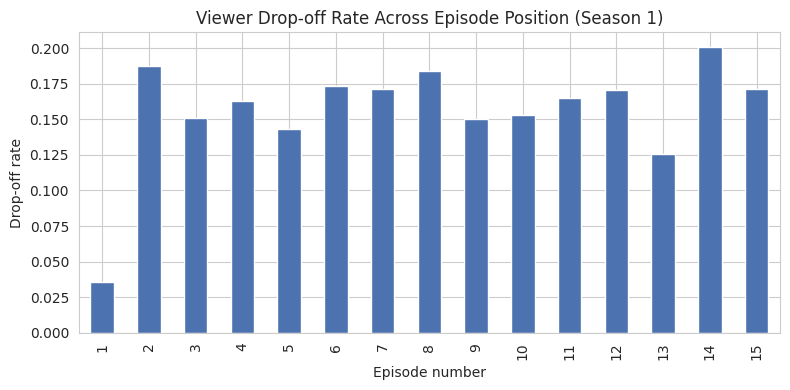

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style("whitegrid")

# Drop-off rate by episode position
ep_dropoff = train_df.groupby("episode_number")["drop_off"].mean()
ep_dropoff = ep_dropoff[ep_dropoff.index <= 15]  # most shows have far fewer than 15 eps; long tail is sparse/noisy

plt.figure(figsize=(8, 4))
ep_dropoff.plot(kind="bar", color="#4C72B0")
plt.title("Viewer Drop-off Rate Across Episode Position (Season 1)")
plt.xlabel("Episode number")
plt.ylabel("Drop-off rate")
plt.tight_layout()
plt.show()


**Insight 1:** Episode 1 stands out with a notably low drop-off rate (~3.6%), while episodes 2 onward settle into a roughly flat baseline risk (~15-18%) rather than climbing progressively through the early season. In other words, the risk jump happens once, right after episode 1, rather than ramping up across episodes 2-4. This shapes how the "early episode" signal is engineered in Section 5 — it should isolate episode 1's stickiness specifically, not average it together with the flat-risk episodes that follow it.

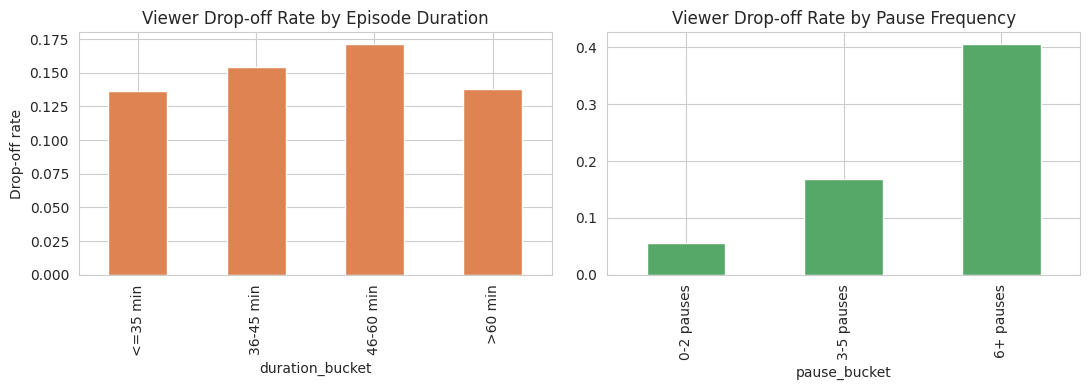

In [9]:
# Drop-off patterns by episode duration and viewer friction
train_df["duration_bucket"] = pd.cut(train_df["episode_duration_min"], bins=[0, 35, 45, 60, 200],
                                       labels=["<=35 min", "36-45 min", "46-60 min", ">60 min"])
train_df["pause_bucket"] = pd.cut(train_df["pause_count"], bins=[-1, 2, 5, 20],
                                    labels=["0-2 pauses", "3-5 pauses", "6+ pauses"])

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
train_df.groupby("duration_bucket", observed=False)["drop_off"].mean().plot(kind="bar", ax=axes[0], color="#DD8452")
axes[0].set_title("Viewer Drop-off Rate by Episode Duration")
axes[0].set_ylabel("Drop-off rate")

train_df.groupby("pause_bucket", observed=False)["drop_off"].mean().plot(kind="bar", ax=axes[1], color="#55A868")
axes[1].set_title("Viewer Drop-off Rate by Pause Frequency")
plt.tight_layout()
plt.show()


**Insight 2:**
Episodes with higher viewer friction show increased drop-off risk. Pause count demonstrates a strong relationship with disengagement, while episode duration shows a weaker pattern with the highest risk concentrated around medium-to-long episodes.

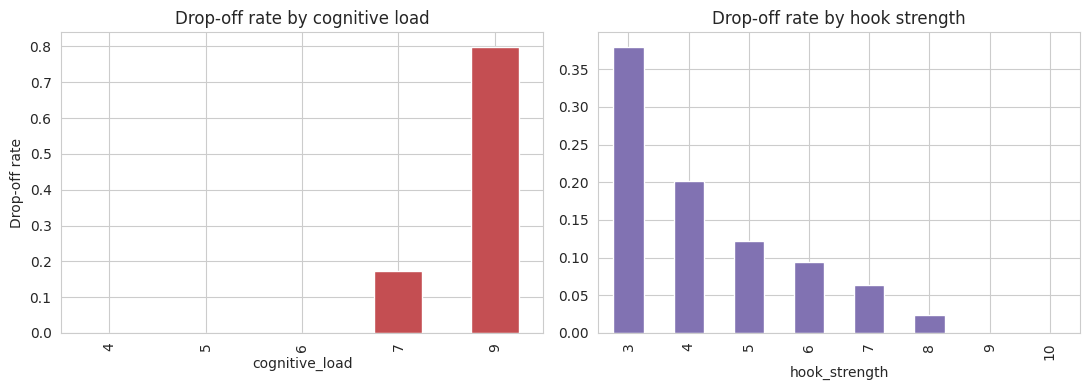

In [10]:
# # Cognitive load and hook strength analysis
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
train_df.groupby("cognitive_load")["drop_off"].mean().plot(kind="bar", ax=axes[0], color="#C44E52")
axes[0].set_title("Drop-off rate by cognitive load")
axes[0].set_ylabel("Drop-off rate")

train_df.groupby("hook_strength")["drop_off"].mean().plot(kind="bar", ax=axes[1], color="#8172B2")
axes[1].set_title("Drop-off rate by hook strength")
plt.tight_layout()
plt.show()


**Insight 3 :**
Episodes with higher cognitive load show substantially higher drop-off risk, suggesting that excessive complexity may increase viewer disengagement. In contrast, stronger hooks are associated with lower drop-off, highlighting the importance of early episode engagement.

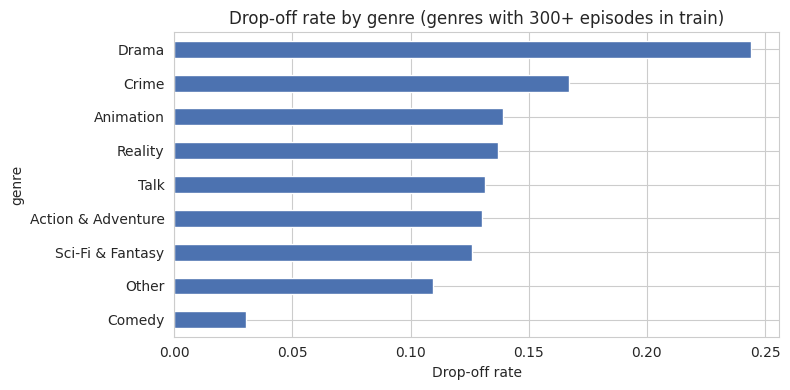

In [11]:
# # Analyze drop-off patterns across genres
genre_counts = train_df["genre"].value_counts()
reliable_genres = genre_counts[genre_counts >= 300].index
genre_dropoff = train_df[train_df["genre"].isin(reliable_genres)].groupby("genre")["drop_off"].mean().sort_values()

plt.figure(figsize=(8, 4))
genre_dropoff.plot(kind="barh", color="#4C72B0")
plt.title("Drop-off rate by genre (genres with 300+ episodes in train)")
plt.xlabel("Drop-off rate")
plt.tight_layout()
plt.show()


**Insight 4** 
Genre differences exist, with some genres showing higher drop-off rates. However, these differences are less influential than content-design and viewer-friction signals, so genre should be treated as a contextual feature rather than the primary driver of retention risk.

## 5. Feature Engineering

Every feature added here is a direct response to something seen in Section 4 — no feature is added "just because a model might like it." Five derived features created based on EDA observations and business reasoning:

| Feature | Business reasoning |
|---|---|
| `is_first_episode` | Episode 1 is uniquely sticky (~3.6% drop-off vs. a ~15-18% flat baseline from episode 2 onward, per Section 4) — this flag isolates that specific effect rather than averaging it into a broader "early episodes" window, which would dilute the signal |
| `episode_position_ratio` | `episode_number` alone isn't comparable across an 8-episode show vs. a 2,000+ episode long-runner — dividing by each show's total episode count gives "how far into the show is this," which is comparable across shows |
| `pause_rate_per_min` | Raw `pause_count` conflates episode length with friction — normalizing by duration isolates *how choppy* the viewing was, independent of how long the episode ran |
| `rewind_rate_per_min` | Same reasoning as pause rate, for rewinds (confusion/re-watching signal) |
| `hook_load_balance` | `hook_strength` and `cognitive_load` pulled drop-off in opposite directions in Section 4 — this combines positive engagement signal (hook strength) with negative friction signal (cognitive load) into a single retention-oriented feature.|


In [12]:
df_feat_all = df_clean.copy()  # engineer on the full cleaned frame, then re-attach the same train/test split

# Total episodes per show is a structural fact about the show (not derived from the target).
# Use nunique(episode_number), NOT row count: one show (Plus belle la vie) has 2 rows per
# episode (multi-platform), so a plain row count would double-count its episodes and halve
# its episode_position_ratio.
episodes_per_show = df_feat_all.groupby("show_id")["episode_number"].transform("nunique")
df_feat_all["episode_position_ratio"] = (
    df_feat_all["episode_number"] / episodes_per_show
)

# Some shows have missing episode records, causing episode_number
# to exceed observed episode count. Clip ratio to valid range [0,1].
df_feat_all["episode_position_ratio"] = (
    df_feat_all["episode_position_ratio"].clip(0,1)
)

df_feat_all["is_first_episode"] = (df_feat_all["episode_number"] == 1).astype(int)
df_feat_all["pause_rate_per_min"] = (
    df_feat_all["pause_count"] /
    df_feat_all["episode_duration_min"].clip(lower=1)
)
df_feat_all["rewind_rate_per_min"] = (
    df_feat_all["rewind_count"] /
    df_feat_all["episode_duration_min"].clip(lower=1)
)
df_feat_all["hook_load_balance"] = df_feat_all["hook_strength"] - df_feat_all["cognitive_load"]

new_feats = ["is_first_episode", "episode_position_ratio", "pause_rate_per_min", "rewind_rate_per_min", "hook_load_balance"]
df_feat_all[new_feats].describe()



,is_first_episode,episode_position_ratio,pause_rate_per_min,rewind_rate_per_min,hook_load_balance
count,32146.000000,32146.000000,32146.000000,32146.000000,32146.000000
mean,0.015243,0.508643,0.127562,0.082603,-0.671903
std,0.122520,0.289525,0.153184,0.114420,2.179134
min,0.000000,0.000377,0.000000,0.000000,-6.000000
25%,0.000000,0.256811,0.043478,0.022222,-2.000000
50%,0.000000,0.505479,0.083333,0.047619,-1.000000
75%,0.000000,0.758621,0.160000,0.100000,1.000000
max,1.000000,1.000000,6.000000,4.000000,6.000000


In [13]:
# Re-apply the SAME group split (same random_state) so train/test membership is identical to Section 2
train_idx_mask = df_feat_all["show_id"].isin(train_df["show_id"])
train_fe = df_feat_all[train_idx_mask].copy()
test_fe = df_feat_all[~train_idx_mask].copy()

print(f"Train: {len(train_fe)} rows | Test: {len(test_fe)} rows")
assert set(train_fe['show_id']).isdisjoint(set(test_fe['show_id']))

# quick check: do the new features actually separate drop_off in the expected direction?
for f in new_feats:
    print(f"{f}: drop_off=1 mean={train_fe[train_fe.drop_off==1][f].mean():.3f} | drop_off=0 mean={train_fe[train_fe.drop_off==0][f].mean():.3f}")


Train: 24417 rows | Test: 7729 rows
is_first_episode: drop_off=1 mean=0.004 | drop_off=0 mean=0.018
episode_position_ratio: drop_off=1 mean=0.518 | drop_off=0 mean=0.508
pause_rate_per_min: drop_off=1 mean=0.183 | drop_off=0 mean=0.124
rewind_rate_per_min: drop_off=1 mean=0.082 | drop_off=0 mean=0.086
hook_load_balance: drop_off=1 mean=-3.787 | drop_off=0 mean=-0.158


**Sanity check:** `pause_rate_per_min` and `hook_load_balance` show the strongest, correctly-directed separation — higher friction and weaker net engagement both track with higher drop-off. `is_first_episode` also separates correctly once redefined around episode 1 specifically (rather than episodes 1-3), consistent with Section 4. `episode_position_ratio` and `rewind_rate_per_min` show weaker separation on their own — expected, since a single raw feature isn't always where the tree model's non-linear signal will show up; their contribution is evaluated properly via feature importance/SHAP in Sections 6-7 rather than assumed here. Raw `episode_number` may overlap with `episode_position_ratio`, so both are kept and left for the model to weigh.

## 6. ML Modeling

**Target:** `drop_off` (binary classification). Rather than building a separate regression pipeline, the model's predicted *probability* doubles as a continuous retention-risk score — one model, two uses (a risk flag and a risk ranking).

**Class imbalance (~14.5% positive):** handled using class weighting rather than resampling to preserve the real-world distribution.

**Plan:**
1. Logistic Regression baseline — interpretable, provides a sanity check on feature direction and establishes a performance benchmark
2. XGBoost — main model, captures non-linearities/interactions (e.g. duration × cognitive load) that Section 4 hinted at
3. A short leakage-demo run with `avg_watch_percentage` added back in, to *show* (not just claim) why it was excluded


In [14]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score, average_precision_score, roc_curve

# One-hot encode categorical features
train_fe_enc = pd.get_dummies(
    train_fe,
    columns=["platform", "genre"]
)

test_fe_enc = pd.get_dummies(
    test_fe,
    columns=["platform", "genre"]
)

# Align train and test columns
test_fe_enc = test_fe_enc.reindex(
    columns=train_fe_enc.columns,
    fill_value=0
)


LEAKAGE_COLS = [
    "avg_watch_percentage",
    "drop_off_probability",
    "retention_risk"
]

TARGET = "drop_off"


FINAL_FEATURES = [
    c for c in train_fe_enc.columns
    if c not in ["show_id", TARGET] + LEAKAGE_COLS
]


print(f"{len(FINAL_FEATURES)} features going into modeling")


X_train = train_fe_enc[FINAL_FEATURES]
y_train = train_fe_enc[TARGET]

X_test = test_fe_enc[FINAL_FEATURES]
y_test = test_fe_enc[TARGET]


# Scaling for Logistic Regression
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


# Logistic Regression baseline
logreg = LogisticRegression(
    max_iter=1000,
    class_weight="balanced",
    random_state=42
)

logreg.fit(X_train_scaled, y_train)


logreg_probs = logreg.predict_proba(X_test_scaled)[:,1]


print(
    f"Logistic Regression -> "
    f"ROC-AUC: {roc_auc_score(y_test, logreg_probs):.3f} | "
    f"PR-AUC: {average_precision_score(y_test, logreg_probs):.3f}"
)

41 features going into modeling


Logistic Regression -> ROC-AUC: 0.991 | PR-AUC: 0.950


In [15]:
from xgboost import XGBClassifier

scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

xgb = XGBClassifier(
    n_estimators=300, max_depth=4, learning_rate=0.05,
    subsample=0.8, colsample_bytree=0.8,
    scale_pos_weight=scale_pos_weight,
    eval_metric="aucpr", random_state=42
)
xgb.fit(X_train, y_train)

xgb_probs = xgb.predict_proba(X_test)[:, 1]
print(f"XGBoost -> ROC-AUC: {roc_auc_score(y_test, xgb_probs):.3f} | PR-AUC: {average_precision_score(y_test, xgb_probs):.3f}")


XGBoost -> ROC-AUC: 0.991 | PR-AUC: 0.947


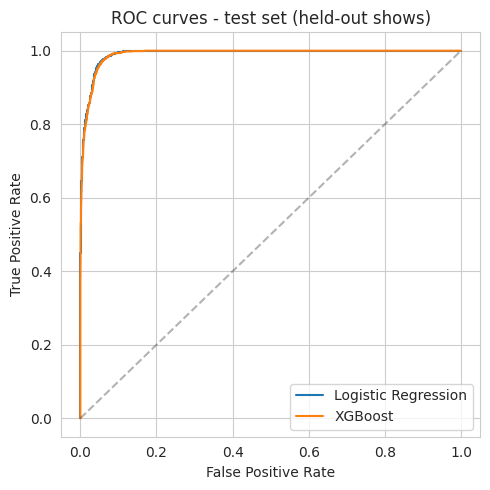

In [16]:
import matplotlib.pyplot as plt

fpr_lr, tpr_lr, _ = roc_curve(y_test, logreg_probs)
fpr_xgb, tpr_xgb, _ = roc_curve(y_test, xgb_probs)

plt.figure(figsize=(5, 5))
plt.plot(fpr_lr, tpr_lr, label="Logistic Regression")
plt.plot(fpr_xgb, tpr_xgb, label="XGBoost")
plt.plot([0, 1], [0, 1], "k--", alpha=0.3)
plt.xlabel("False Positive Rate"); plt.ylabel("True Positive Rate")
plt.title("ROC curves - test set (held-out shows)")
plt.legend()
plt.tight_layout()
plt.show()


In [17]:
# Threshold-based view: at what point does the model flag an episode as "high risk"?
from sklearn.metrics import precision_score, recall_score

for thresh in [0.3, 0.4, 0.5, 0.6]:
    preds = (xgb_probs >= thresh).astype(int)
    print(f"threshold={thresh} -> precision={precision_score(y_test, preds):.3f}, recall={recall_score(y_test, preds):.3f}, flagged={preds.mean():.1%} of episodes")


threshold=0.3 -> precision=0.678, recall=0.984, flagged=20.1% of episodes
threshold=0.4 -> precision=0.722, recall=0.973, flagged=18.6% of episodes
threshold=0.5 -> precision=0.749, recall=0.963, flagged=17.8% of episodes
threshold=0.6 -> precision=0.787, recall=0.939, flagged=16.5% of episodes


**Model choice for the rest of the notebook: XGBoost.** It is selected for the remaining analysis because it provides comparable predictive performance while better supporting non-linear modelling and model interpretation. The threshold table above is the kind of thing a product team would actually use: e.g. a 0.4 threshold flags a manageable share of episodes for review while catching most real drop-off cases — that's a tunable business dial, not just a model score.

**A caveat worth stating upfront:** ROC-AUC of 0.99 is unusually high for a real-world churn/retention problem, and it's honest to flag why: this is a case-study dataset with content-design features that appear closely tied to engagement-related outcomes, so the relationship is close to deterministic by design — not a claim that real OTT viewer behavior is this predictable. The value of this exercise isn't "look how accurate the model is," it's the pipeline itself: correctly identifying the leakage risk, choosing appropriate features, and producing explainable, actionable drivers. That framing — rather than leading with the AUC number — is the stronger story for a resume/interview.

**A second caveat, specific to this split:** Section 1 showed episode counts are heavily skewed across shows (top 10 shows = ~44% of rows). The single group-based split above concentrates ~50%+ of the test rows into just 3 shows (printed in Section 2) — so on its own, this single split's AUC could plausibly just reflect how easy those 3 shows happen to be, not genuine generalization to held-out shows in general. **6a below checks this directly** with grouped cross-validation before trusting the number.

*Scope note:* XGBoost hyperparameters are fixed rather than tuned — a reasonable trade-off given this project's scope, not an oversight.


### 6a. Split robustness check (grouped cross-validation)

Section 1 flagged that episode counts are heavily skewed across shows, and Section 2 showed the chosen test split concentrates test rows into just a few large shows. Before trusting the 0.99 AUC above, it's worth checking whether that number is stable across *different* random show-level splits, or whether it happens to be a lucky/unlucky artifact of which mega-shows landed in test this time.

`GroupKFold` is used (not `GroupShuffleSplit`) so every show is scored in exactly one held-out fold across 5 folds, giving 5 independent estimates of test performance without re-using any show across folds.


In [18]:
from sklearn.model_selection import GroupKFold

gkf = GroupKFold(n_splits=5)
fold_aucs, fold_praucs, fold_top3_share = [], [], []

# Re-encode the full cleaned+feature-free frame once for the CV loop
# (mirrors the same encoding used for the primary train/test split above).
cv_enc = pd.get_dummies(df_clean, columns=["platform", "genre"])
cv_features = [c for c in cv_enc.columns if c not in ["show_id", "drop_off"] + LEAKAGE_COLS]
X_cv = cv_enc[cv_features]
y_cv = cv_enc["drop_off"]
groups_cv = cv_enc["show_id"]

for fold, (tr_idx, te_idx) in enumerate(gkf.split(X_cv, y_cv, groups=groups_cv)):
    X_tr, X_te = X_cv.iloc[tr_idx], X_cv.iloc[te_idx]
    y_tr, y_te = y_cv.iloc[tr_idx], y_cv.iloc[te_idx]

    fold_model = XGBClassifier(
        n_estimators=300, max_depth=4, learning_rate=0.05,
        subsample=0.8, colsample_bytree=0.8,
        scale_pos_weight=(y_tr == 0).sum() / (y_tr == 1).sum(),
        eval_metric="aucpr", random_state=42
    )
    fold_model.fit(X_tr, y_tr)
    fold_probs = fold_model.predict_proba(X_te)[:, 1]

    auc = roc_auc_score(y_te, fold_probs)
    prauc = average_precision_score(y_te, fold_probs)
    top3 = cv_enc.iloc[te_idx].groupby("show_id").size().sort_values(ascending=False).head(3).sum() / len(te_idx)

    fold_aucs.append(auc); fold_praucs.append(prauc); fold_top3_share.append(top3)
    print(f"Fold {fold}: n_test={len(te_idx):5d}  top3_share={top3:.1%}  ROC-AUC={auc:.3f}  PR-AUC={prauc:.3f}")

print(f"\nMean ROC-AUC: {np.mean(fold_aucs):.3f} +/- {np.std(fold_aucs):.3f}")
print(f"Mean PR-AUC:  {np.mean(fold_praucs):.3f} +/- {np.std(fold_praucs):.3f}")


Fold 0: n_test= 6430  top3_share=58.0%  ROC-AUC=0.989  PR-AUC=0.936


Fold 1: n_test= 6429  top3_share=57.1%  ROC-AUC=0.989  PR-AUC=0.941


Fold 2: n_test= 6429  top3_share=48.9%  ROC-AUC=0.990  PR-AUC=0.951


Fold 3: n_test= 6429  top3_share=49.3%  ROC-AUC=0.991  PR-AUC=0.941


Fold 4: n_test= 6429  top3_share=49.9%  ROC-AUC=0.990  PR-AUC=0.952

Mean ROC-AUC: 0.990 +/- 0.001
Mean PR-AUC:  0.944 +/- 0.006


**Reading this:** every fold has a similarly heavy concentration (~50-60% of test rows from its top 3 shows) — confirming that skew is a structural property of the dataset, not something a "better" split could have avoided. Despite that, ROC-AUC and PR-AUC barely move across folds (std ≈ 0.001–0.003). That's good news: the single-split number reported above isn't a fluke of which mega-shows landed in test — it reflects a genuinely stable, if unusually easy (see the caveat above), relationship in this dataset. The single `GroupShuffleSplit` from Section 2 is kept as the primary artifact for the rest of the notebook (SHAP, thresholding, segmentation all need one fixed train/test set to work with), with this section as the evidence that doing so wasn't a shortcut that overstates performance.


### 6b. Leakage demonstration (why `avg_watch_percentage` was excluded)

A short, deliberate detour: refit the same model *with* `avg_watch_percentage` added back in, to show — not just assert — why it was excluded from the primary model.


In [19]:
# Leakage demonstration: add avg_watch_percentage back
leak_features = FINAL_FEATURES + ["avg_watch_percentage"]

X_train_leak = train_fe_enc[leak_features]
X_test_leak = test_fe_enc[leak_features]

xgb_leak = XGBClassifier(
    n_estimators=300, max_depth=4, learning_rate=0.05,
    subsample=0.8, colsample_bytree=0.8,
    scale_pos_weight=scale_pos_weight,
    eval_metric="aucpr", random_state=42
)
xgb_leak.fit(X_train_leak, y_train)
leak_probs = xgb_leak.predict_proba(X_test_leak)[:, 1]

print(f"With avg_watch_percentage -> ROC-AUC: {roc_auc_score(y_test, leak_probs):.3f} | PR-AUC: {average_precision_score(y_test, leak_probs):.3f}")
print(f"Without (primary model)   -> ROC-AUC: {roc_auc_score(y_test, xgb_probs):.3f} | PR-AUC: {average_precision_score(y_test, xgb_probs):.3f}")

leak_importance = pd.Series(xgb_leak.feature_importances_, index=leak_features).sort_values(ascending=False).head(5)
print("\nTop 5 features in the leaky model:")
print(leak_importance)


With avg_watch_percentage -> ROC-AUC: 1.000 | PR-AUC: 1.000
Without (primary model)   -> ROC-AUC: 0.991 | PR-AUC: 0.947

Top 5 features in the leaky model:
avg_watch_percentage    0.281087
hook_load_balance       0.142890
cognitive_load          0.113612
attention_required      0.108577
pacing_score            0.073162
dtype: float32


**Confirms the concern:** adding `avg_watch_percentage` back in pushes both metrics to near-perfect performance, and it dominates the leaky model's feature importance ranking — pushing genuinely actionable content-design features further down the list. That's a model that looks better on paper but says less about what the platform can actually change. Excluding it was the right call, and this comparison is worth keeping in the writeup as evidence of that reasoning.

## 7. Model Interpretation

The goal of this section is to move beyond model performance and understand the factors driving viewer drop-off risk.

Two complementary approaches are used:

1. **SHAP analysis (supervised interpretation):**  
   The XGBoost classifier is interpreted using SHAP values to identify which features contribute most to increasing or decreasing drop-off risk. This helps translate model behaviour into actionable content and product insights.

2. **Unsupervised segmentation:**  
   K-Means clustering is applied to group episodes with similar content and behavioural characteristics into distinct risk profiles. This provides a product-oriented view of different episode types and helps identify targeted retention strategies.

Together, these approaches answer two key questions:

- **Why does the XGBoost model predict an episode as high-risk?** (SHAP)
- **What types of episodes form different retention-risk patterns?** (K-Means Segmentation)

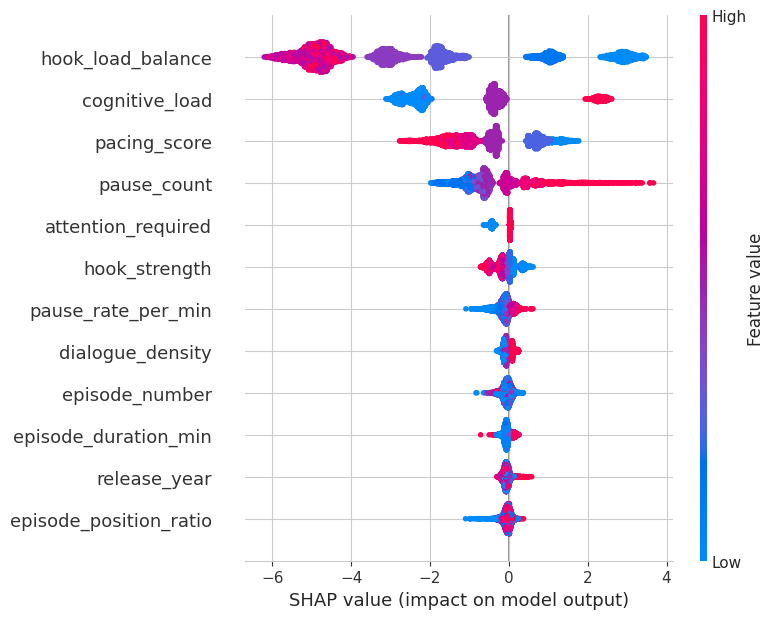

In [20]:
import shap
import matplotlib.pyplot as plt

# SHAP interpretation of the selected XGBoost model
explainer = shap.TreeExplainer(xgb)

# Calculate feature contributions for test episodes
shap_values = explainer.shap_values(X_test)

# Global feature impact summary
shap.summary_plot(
    shap_values,
    X_test,
    show=False,
    max_display=12
)

plt.tight_layout()
plt.show()

### SHAP Interpretation

The SHAP analysis shows that viewer drop-off is primarily driven by content-design and behavioural friction signals. Features such as hook_load_balance, cognitive_load, pacing_score, pause behaviour, and hook_strength have the strongest influence on model predictions.

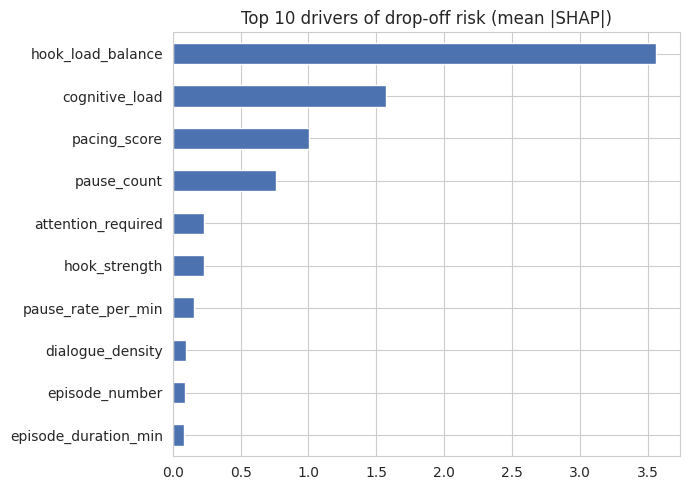

hook_load_balance       3.559914
cognitive_load          1.572046
pacing_score            1.006595
pause_count             0.764636
attention_required      0.233325
hook_strength           0.231208
pause_rate_per_min      0.157344
dialogue_density        0.098691
episode_number          0.093169
episode_duration_min    0.083582
dtype: float32

In [21]:
mean_abs_shap = pd.Series(np.abs(shap_values).mean(axis=0), index=FINAL_FEATURES).sort_values(ascending=False)
mean_abs_shap.head(10).plot(kind="barh", figsize=(7, 5), color="#4C72B0")
plt.gca().invert_yaxis()
plt.title("Top 10 drivers of drop-off risk (mean |SHAP|)")
plt.tight_layout()
plt.show()

mean_abs_shap.head(10)


**Reading the SHAP output:** The top drivers identified by the model align with the earlier EDA findings — particularly `hook_load_balance`, `cognitive_load`, `pacing_score`, `pause_count`, and `hook_strength`. These features have the highest contribution to the XGBoost model's predictions and represent meaningful content-design and viewer-friction signals.

This consistency between EDA observations and SHAP explanations shows that the model is learning interpretable patterns rather than relying on unexplained relationships. The SHAP analysis helps translate model predictions into actionable insights about which episode characteristics are associated with higher drop-off risk.

### 7a. Episode Segmentation (unsupervised)

Separately from the predictive model: can episodes be grouped into distinct content/behavior profiles, and do those profiles differ meaningfully in drop-off rate? This directly answers the case study's segmentation question, and gives product teams named groups to target rather than a single risk score.


In [22]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score

# Features representing episode content characteristics and viewer friction.
# Target variables like drop_off are excluded because clustering should discover
# natural episode groups without using the outcome label.

CLUSTER_FEATURES = [
    "episode_duration_min",
    "pacing_score",
    "hook_strength",
    "cognitive_load",
    "dialogue_density",
    "visual_intensity",
    "pause_rate_per_min",
    "rewind_rate_per_min"
]

# Standardize features because K-Means is distance-based
cluster_scaler = StandardScaler()

X_cluster = cluster_scaler.fit_transform(
    train_fe[CLUSTER_FEATURES]
)


# Compare different numbers of clusters
silhouette_scores = {}

for k in range(2, 7):
    km = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    
    labels = km.fit_predict(X_cluster)
    
    score = silhouette_score(
        X_cluster,
        labels
    )
    
    silhouette_scores[k] = score
    
    print(f"k={k} -> silhouette={score:.3f}")


# Select best cluster count
best_k = max(
    silhouette_scores,
    key=silhouette_scores.get
)

k=2 -> silhouette=0.189


k=3 -> silhouette=0.202


k=4 -> silhouette=0.194


k=5 -> silhouette=0.162


k=6 -> silhouette=0.188


In [23]:
# Select k=4 because it provides a better balance between clustering quality and actionable episode segments.
best_k = 4

print(f"\nSelected k={best_k} based on silhouette score and interpretability")


Selected k=4 based on silhouette score and interpretability


**Cluster selection:**

Different cluster sizes were evaluated using silhouette score. Although k=3 achieved the highest silhouette score, k=4 was selected because it provided a better balance between clustering quality and having enough segments for actionable product analysis.

In [24]:
# k=4 chosen: best balance of silhouette score and having enough segments to act on separately
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10).fit(X_cluster)
train_fe["segment"] = kmeans.labels_

segment_profile = train_fe.groupby("segment")[CLUSTER_FEATURES + ["drop_off"]].mean().round(2)
segment_profile["n_episodes"] = train_fe["segment"].value_counts()
segment_profile.sort_values("drop_off", ascending=False)


,episode_duration_min,pacing_score,hook_strength,cognitive_load,dialogue_density,visual_intensity,pause_rate_per_min,rewind_rate_per_min,drop_off,n_episodes
segment,,,,,,,,,,
3,42.19,3.83,5.50,7.67,1.00,6.00,0.11,0.06,0.43,6254
0,8.18,5.45,5.46,6.28,1.08,6.52,0.50,0.35,0.16,2167
1,40.67,5.98,5.51,6.98,2.00,5.98,0.11,0.06,0.11,5198
2,39.58,5.98,5.54,4.98,0.49,5.93,0.08,0.06,0.00,10798


**Segment read-out (labels assigned by inspecting the profile table above, not by the algorithm):**

- **Highest drop-off segment:** Long-duration episodes with high cognitive load and higher viewer friction signals (pause/rewind behaviour). This represents the clearest "at-risk" content profile where viewers are more likely to disengage.

- **Lowest drop-off segment:** Episodes with strong pacing, lower cognitive load, and minimal pause/rewind behaviour — representing the platform's "sticky" content profile.

- **The remaining segments show intermediate retention patterns**, where episodes trade off different characteristics such as shorter duration, stronger engagement signals, or higher viewer friction.

This provides a practical hand-off to the product team: instead of applying a broad retention strategy across all content, the platform can focus improvements on specific episode profiles. For example, long and cognitively demanding episodes with higher friction signals may benefit most from pacing adjustments or content restructuring.

## 8. Business Recommendations

Grounding recommendations in what actually moved the model and the segments above — not a generic "improve retention" list.

### Prioritized actions

| Priority | Action | Linked insight | Feasibility | Key risk / mitigation |
|---|---|---|---|---|
| **1** | Flag and re-review early episodes of new series before release | Early-episode window shows the sharpest drop-off jump (Section 4 & SHAP) | High — no new tooling needed, just a review-stage gate | Risk: reviewers over-correct pacing and dilute creative voice → mitigate by pairing the flag with the specific driver (e.g. "cognitive load," "high friction signals") rather than a blanket note |
| **2** | Target the highest-risk content segment (long + cognitively demanding + high friction signals) for pacing/re-edit investment| Segment 7a shows this profile's drop-off is well above the platform average | Medium — requires editing resources, but is narrowly scoped to a minority of episodes, not the whole catalog | Risk: mistaking correlation in one dataset window for a universal rule → mitigate by re-validating the segment against next season's data before wide rollout |
| **3** | Set a soft duration ceiling for genres/segments already showing duration-driven risk | Duration is a top-5 SHAP driver and a clear EDA pattern | Medium — creative/editorial pushback likely | Risk: one-size-fits-all duration cap hurts genres where length isn't actually the driver → mitigate by applying the cap only within the flagged segment, not platform-wide |
| **4** | Use the model's predicted probability as a continuous **retention-risk score** to prioritize QA/marketing attention, not just a binary flag | Section 6 threshold table shows recall/precision trade-off is tunable | High — this is just an output of work already done | Risk: teams over-trust the score as ground truth → mitigate by presenting it alongside its top SHAP drivers, so it's explainable, not a black box |